In [2]:
# Libraries for data handling and model training
import numpy as np
import pandas as pd


# TensorFlow and Keras for building the CNN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from datasets import load_dataset


2026-02-20 20:05:05.670360: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-20 20:05:05.670596: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-20 20:05:05.706668: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-20 20:05:06.768694: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [13]:
ds = load_dataset("regularpooria/tinynav_depth_camera_circuits")
rows = []
for example in ds["train"]:
    rows.append({
        "image": np.array(example["image"], dtype=np.float32),
        "steering": float(example["steering"]),
        "throttle": float(example["throttle"]),
    })

df = pd.DataFrame(rows)

In [14]:
df

,image,steering,throttle
0,"[[2550.0, 2550.0, 2550.0, 970.0, 960.0, 970.0,...",-0.015,0.025
1,"[[2550.0, 2550.0, 2550.0, 980.0, 960.0, 970.0,...",-0.015,0.023
2,"[[2550.0, 2550.0, 990.0, 950.0, 940.0, 950.0, ...",-0.035,0.694
3,"[[2550.0, 2550.0, 2550.0, 2550.0, 1320.0, 1160...",-0.035,0.694
4,"[[2550.0, 2550.0, 2550.0, 2550.0, 2550.0, 1130...",-0.035,0.694
...,...,...,...
44919,"[[2550.0, 2550.0, 2550.0, 2550.0, 1610.0, 1660...",-0.013,0.815
44920,"[[2550.0, 2550.0, 2550.0, 2550.0, 2550.0, 1710...",-0.011,0.756
44921,"[[2550.0, 2550.0, 2550.0, 2550.0, 2550.0, 1720...",-0.013,0.678
44922,"[[2550.0, 2550.0, 2550.0, 2550.0, 2550.0, 1710...",-0.013,0.658


In [17]:
from sklearn.utils import shuffle
import cv2
H=25 
W=25
# Targets: steering + throttle (kept as regression in normalized units)
Y_all = df[["steering", "throttle"]].to_numpy(dtype=np.float32)

# Inputs: depth grid as a single-channel 25x25 image + rotate
X_all = np.stack(df["image"].values).astype(np.float32)
X_all = np.rot90(
    X_all.reshape(-1, H, W, 1),
    k=-1,
    axes=(1, 2)
)
X_all = X_all / 2550.0

# Resize from 25×25 to target size
def resize_data(X, target_size=(24, 24)):
    """Resize images efficiently"""
    n_samples = X.shape[0]
    X_resized = np.zeros((n_samples, target_size[0], target_size[1], 1), dtype=np.float32)
    
    for i in range(n_samples):
        X_resized[i, :, :, 0] = cv2.resize(
            X[i, :, :, 0], 
            target_size, 
            interpolation=cv2.INTER_AREA  # Best for downsampling
        )
    
    return X_resized
  
# Apply resize
X_all = resize_data(X_all, target_size=(24, 24))
print(X_all.shape)


(44924, 24, 24, 1)


In [18]:
FRAMES_PER_BLOCK = 20

In [22]:
def create_blocks(X: np.ndarray, Y: np.ndarray, frame_count: int = 6, stride: int = 1):
    n = X.shape[0]
    
    blocks = []
    labels = []
    
    for start in range(0, n - frame_count + 1, stride):
        end = start + frame_count
        blocks.append(X[start:end])
        labels.append(Y[end - 1])
    
    X_grouped = np.array(blocks)
    Y_grouped = np.array(labels)
    
    # Remove last singleton channel
    X_grouped = np.squeeze(X_grouped, axis=-1)
    
    # Move time dimension to channel axis
    X_grouped = np.transpose(X_grouped, (0, 2, 3, 1))
    
    return X_grouped, Y_grouped


X, Y = create_blocks(X_all, Y_all, FRAMES_PER_BLOCK, 10)
print(X.shape)
print(Y.shape)

(4491, 24, 24, 20)
(4491, 2)


In [23]:
# ---- Create flipped copy ----
X_flip = np.flip(X, axis=2)      # horizontal flip (width axis)
Y_flip = Y.copy()
Y_flip[:, 0] = -Y_flip[:, 0]         # invert steering only

# ---- Append to original ----
X = np.concatenate([X, X_flip], axis=0)
Y = np.concatenate([Y, Y_flip], axis=0)


# ---- Shuffle the data ----
X, Y = shuffle(X, Y, random_state=42)

print("X:", X.shape)
print("Y shape:", Y.shape)
print("Y min/max:", Y.min(axis=0), Y.max(axis=0))

X: (8982, 24, 24, 20)
Y shape: (8982, 2)
Y min/max: [-1. -1.] [1. 1.]


In [24]:

from sklearn.model_selection import train_test_split

# First split: train (80%) and temp (20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

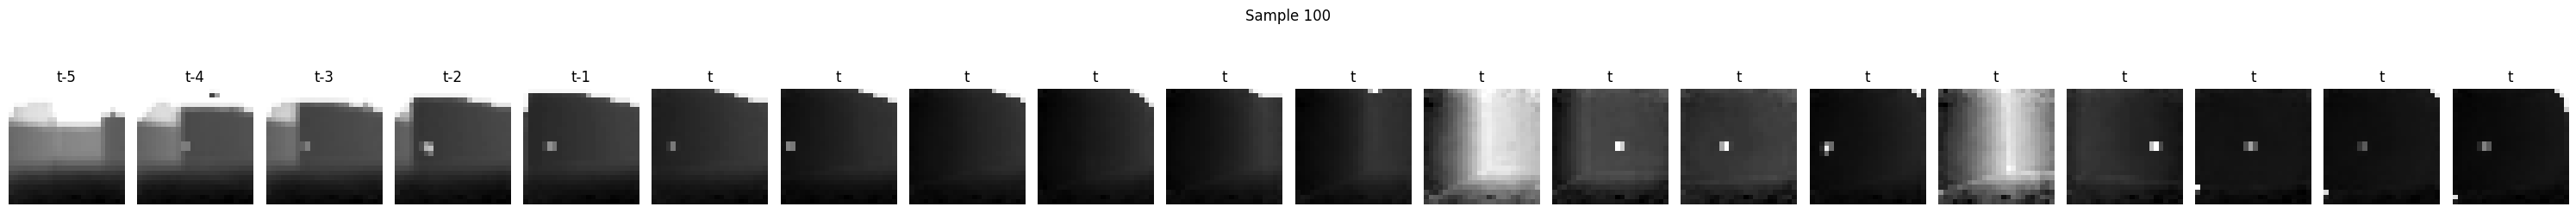

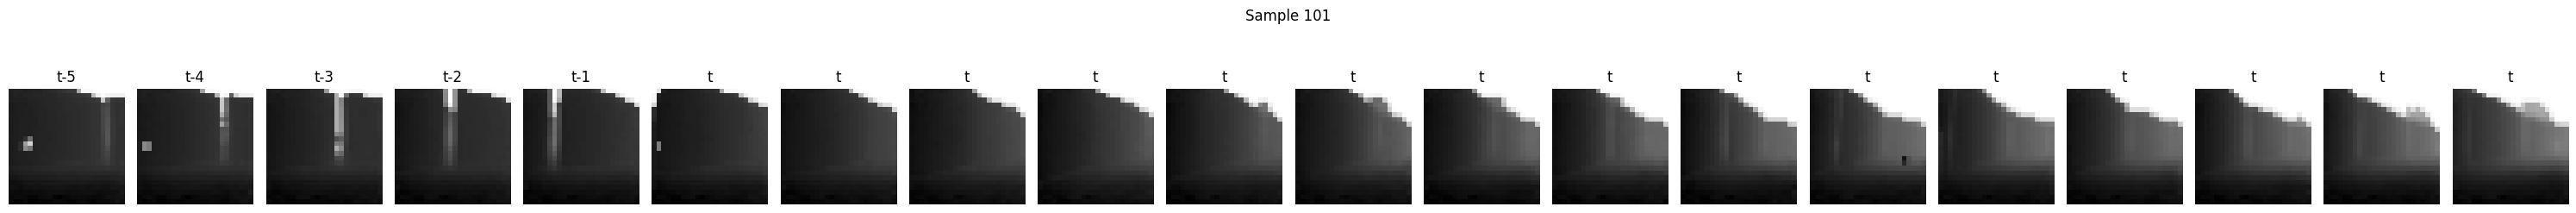

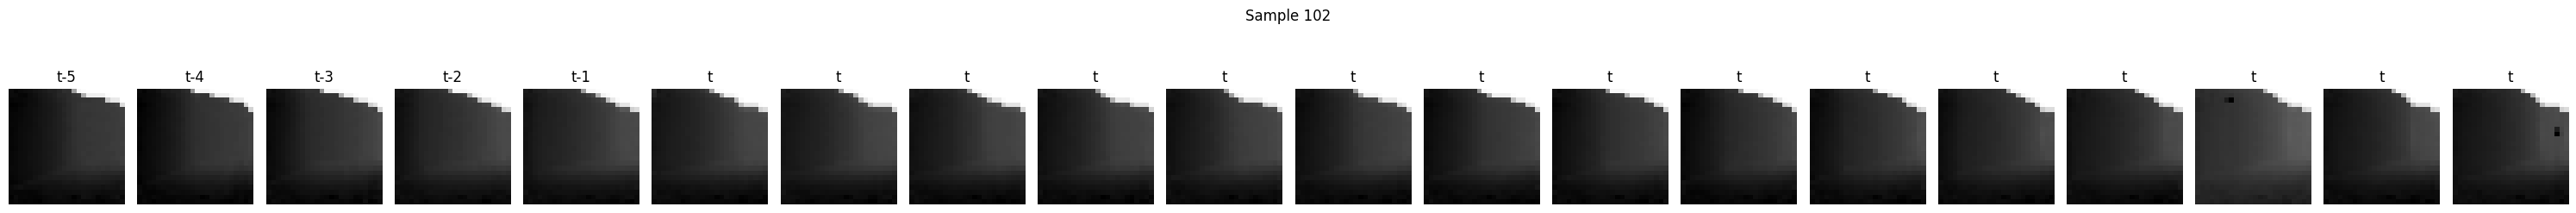

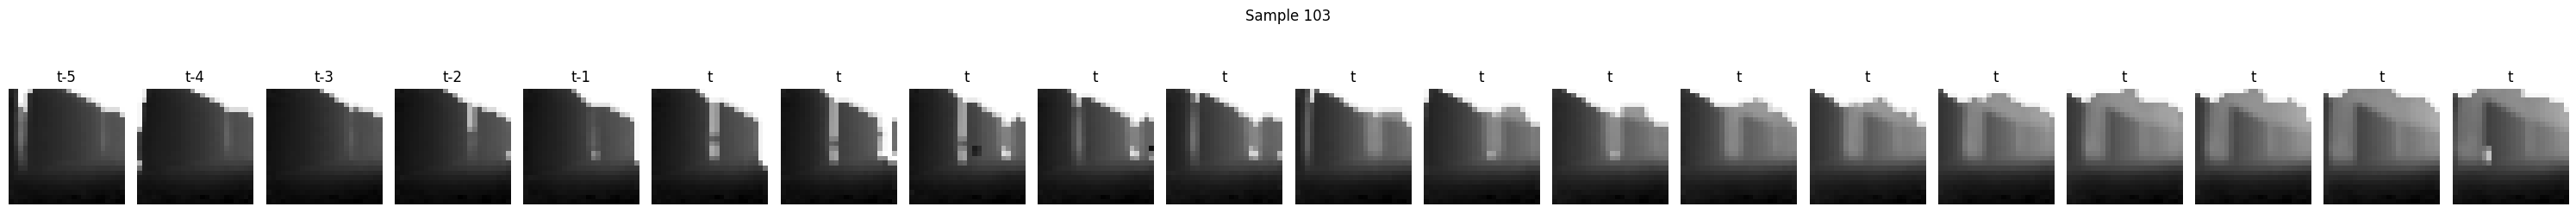

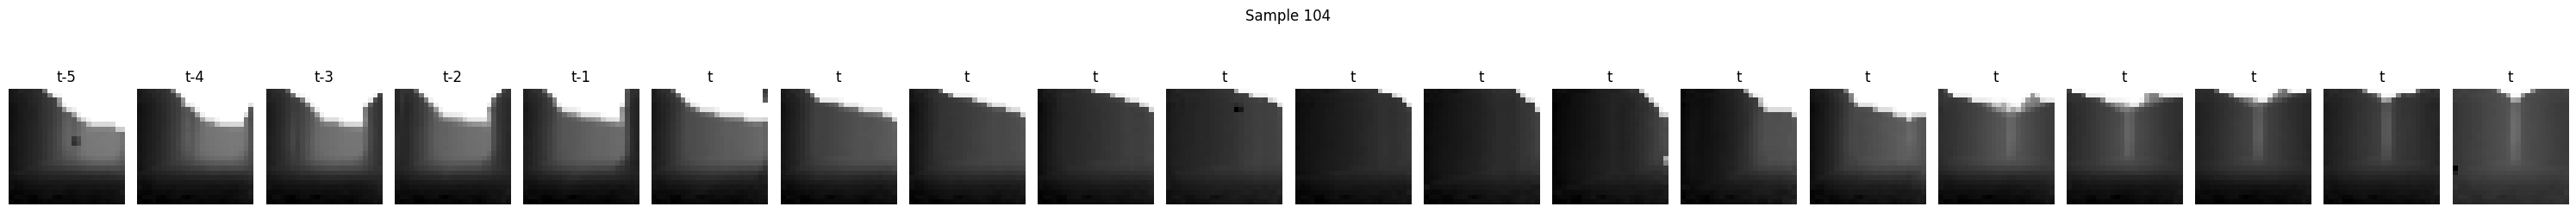

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Show 5 samples
for i in range(100, 105):
    fig, axes = plt.subplots(1, FRAMES_PER_BLOCK, figsize=(30, 3))
    
    for j in range(FRAMES_PER_BLOCK):
        axes[j].imshow(X[i, :, :, j], cmap='gray')
        axes[j].axis("off")
        axes[j].set_title(f"t-{5-j}" if j < 5 else "t")
    
    fig.suptitle(f"Sample {i}")
    plt.tight_layout()
    plt.show()


In [26]:
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
# --------------------------------------------------
# Input
# --------------------------------------------------
# 24x24 image with FRAMES_PER_BLOCK channels
inputs = Input(shape=(24, 24, FRAMES_PER_BLOCK))

# --------------------------------------------------
# Feature Extraction (Downsampling + Convolutions)
# --------------------------------------------------

# First convolution (standard Conv2D)
# Reduces spatial size: 24x24 → 12x12
x = layers.Conv2D(
    filters=16,
    kernel_size=3,
    strides=2,
    padding="same",
    activation="relu6"
)(inputs)

# Second convolution (standard Conv2D)
# Reduces spatial size: 12x12 → 6x6
x = layers.Conv2D(
    filters=32,
    kernel_size=3,
    strides=2,
    padding="same",
    activation="relu6"
)(x)

# Additional feature refinement (standard Conv2D)
x = layers.Conv2D(
    filters=32,
    kernel_size=3,
    padding="same",
    activation="relu6"
)(x)

x = layers.Conv2D(
    filters=48,
    kernel_size=3,
    padding="same",
    activation="relu6"
)(x)


# --------------------------------------------------
# Spatial Attention
# --------------------------------------------------
attention_map = layers.Conv2D(
    filters=1,
    kernel_size=1,
    activation="sigmoid"
)(x)

x = layers.Multiply()([x, attention_map])

# --------------------------------------------------
# Global Feature Aggregation
# --------------------------------------------------
x = layers.GlobalAveragePooling2D()(x)

# --------------------------------------------------
# Regression Head
# --------------------------------------------------
x = layers.Dense(48, activation="relu6")(x)
x = layers.Dropout(0.4)(x)

# from tensorflow.keras.initializers import Constant

# Compute mean of training targets
steering_mean = Y[:, 0].mean()   # steering column
throttle_mean = Y[:, 1].mean()   # throttle column

# Define output layers with bias initialized
steering_output = layers.Dense(
    1,
    activation="tanh",
    name="steering",
    # bias_initializer=Constant(steering_mean)
)(x)

throttle_output = layers.Dense(
    1,
    activation="sigmoid",
    name="throttle",
    # bias_initializer=Constant(throttle_mean)
)(x)
# --------------------------------------------------
# Model Definition
# --------------------------------------------------
model = Model(
    inputs=inputs,
    outputs=[steering_output, throttle_output]
)

# --------------------------------------------------
# Compile
# --------------------------------------------------
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss={
        "steering": "mse",
        "throttle": "mae"
    },
    metrics={
        "steering": ["mae"],
        "throttle": ["mae"]
    }
)

model.summary()


2026-02-20 20:11:50.930173: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 24,    │          0 │ -                 │
│ (InputLayer)        │ 20)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 12, 12,    │      2,896 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 6, 6, 32)  │      4,640 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 6, 6, 32)  │      9,248 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 6, 6, 48)  │     13,872 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 6, 6, 1)   │         49 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 6, 6, 48)  │          0 │ conv2d_3[0][0],   │
│                     │                   │            │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 48)        │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 48)        │      2,352 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 48)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ steering (Dense)    │ (None, 1)         │         49 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ throttle (Dense)    │ (None, 1)         │         49 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 33,155 (129.51 KB)

 Trainable params: 33,155 (129.51 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard
import datetime

# Create callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'output/best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    TensorBoard(
        log_dir=f'logs/{datetime.datetime.now().strftime("%Y%m%d-%H%M%S")}',
        histogram_freq=1
    )
]

# Train using combined control output
history = model.fit(
    X_train,
    {
        "steering": y_train[:, 0],   # First column: steering
        "throttle": y_train[:, 1]    # Second column: throttle
    },
    validation_data=(
        X_temp, 
        {
            "steering": y_temp[:, 0],
            "throttle": y_temp[:, 1]
        }
    ),
    epochs=150,
    batch_size=16,
    callbacks=callbacks
)


Epoch 1/150
447/450 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2066 - steering_loss: 0.0488 - steering_mae: 0.1565 - throttle_loss: 0.1578 - throttle_mae: 0.1578
Epoch 1: val_loss improved from None to 0.17223, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1897 - steering_loss: 0.0445 - steering_mae: 0.1457 - throttle_loss: 0.1448 - throttle_mae: 0.1451 - val_loss: 0.1722 - val_steering_loss: 0.0352 - val_steering_mae: 0.1278 - val_throttle_loss: 0.1369 - val_throttle_mae: 0.1369 - learning_rate: 0.0010
Epoch 2/150
439/450 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1767 - steering_loss: 0.0379 - steering_mae: 0.1304 - throttle_loss: 0.1389 - throttle_mae: 0.1389
Epoch 2: val_loss improved from 0.17223 to 0.15551, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1706 - steering_loss: 0.0360 - steering_mae: 0.1272

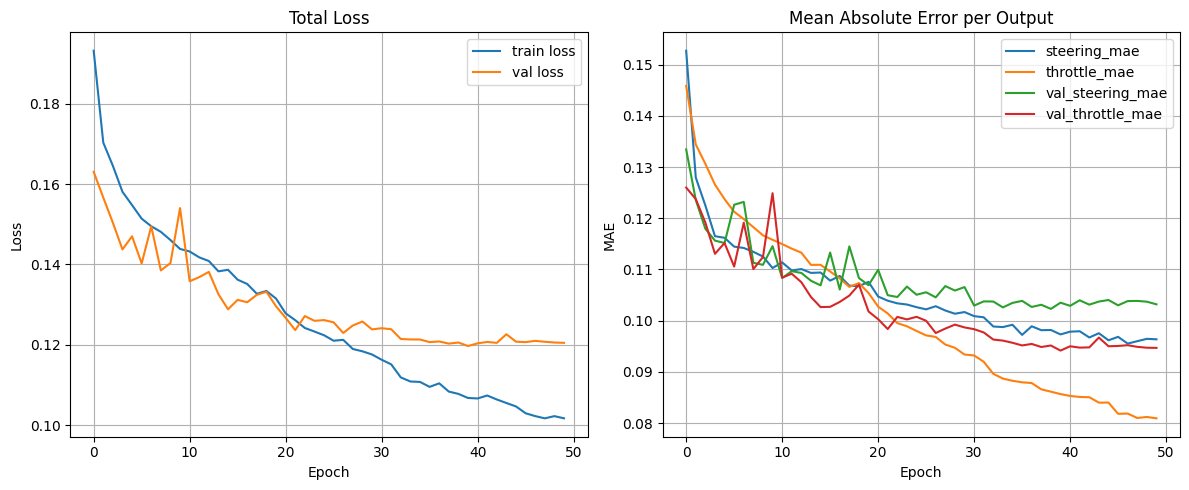

In [51]:
import matplotlib.pyplot as plt

def plot_learning_curves(history):
    # ---- Total Loss ----
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Total Loss")
    plt.legend()
    plt.grid(True)
    6,
    # ---- Output-wise MAE ----
    plt.subplot(1, 2, 2)
    
    for key in history.history.keys():
        if "mae" in key:
            plt.plot(history.history[key], label=key)
    
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.title("Mean Absolute Error per Output")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
plot_learning_curves(history)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


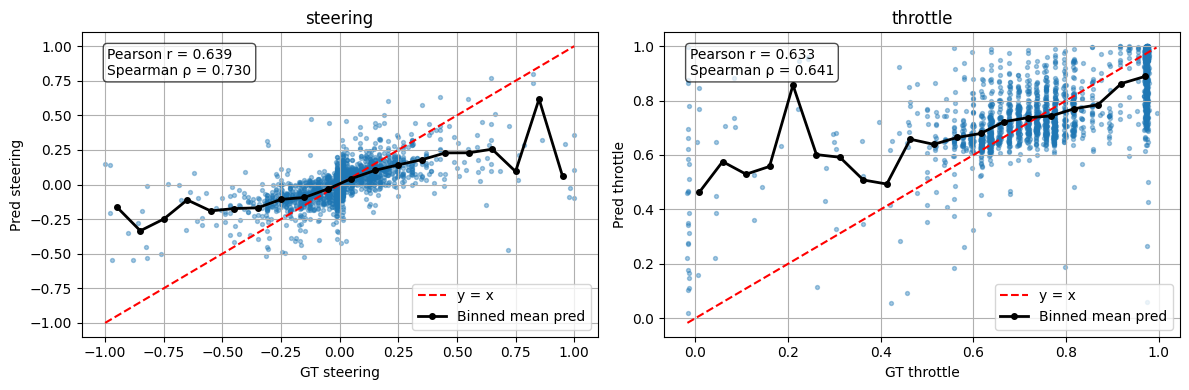

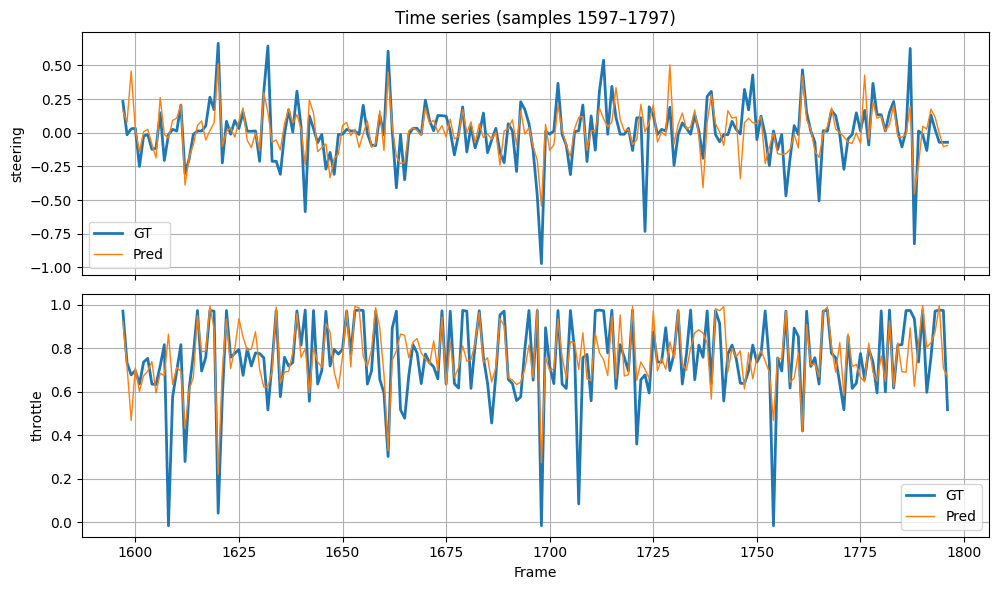

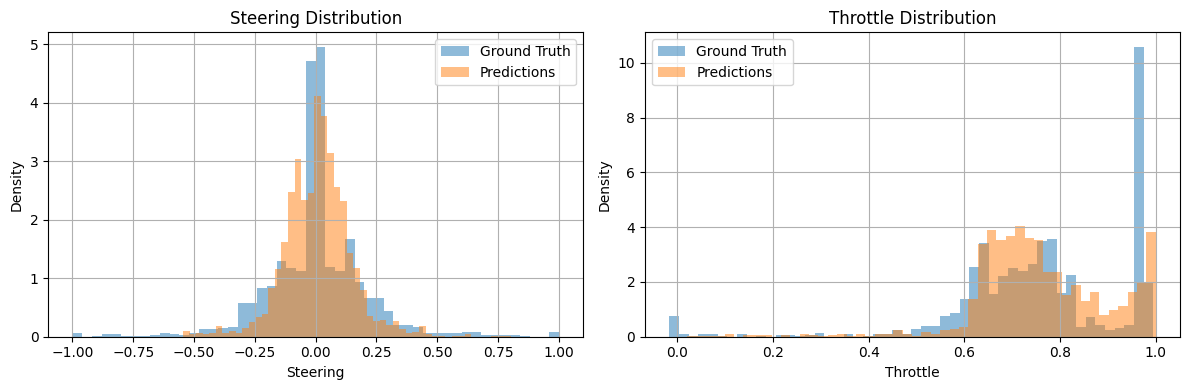

In [52]:

from scipy.stats import spearmanr
import numpy as np
import matplotlib.pyplot as plt

# Get predictions
y_pred = model.predict(X_temp, batch_size=64)

# Handle multi-output model
if isinstance(y_pred, list):  # separate outputs
    y_pred_steering = y_pred[0].ravel()
    y_pred_throttle = y_pred[1].ravel()
    y_pred_combined = np.stack([y_pred_steering, y_pred_throttle], axis=1)
else:  # single concatenated output
    y_pred_combined = y_pred
    y_pred_steering = y_pred[:, 0]
    y_pred_throttle = y_pred[:, 1]

# Compute throttle delta
y_pred_throttle_delta = np.diff(y_pred_throttle, prepend=y_pred_throttle[0])

def plot_pred_vs_gt_with_bins(
    y_true,
    y_pred,
    names=("steering", "throttle"),
    n_bins=20,
):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    for i, ax in enumerate(axes):
        yt = y_true[:, i].ravel()
        yp = y_pred[:, i].ravel()
        
        # Scatter plot
        ax.scatter(yt, yp, s=8, alpha=0.4)
        
        # Perfect prediction line
        lo, hi = yt.min(), yt.max()
        ax.plot([lo, hi], [lo, hi], "r--", label="y = x")
        
        # Correlations
        pearson = np.corrcoef(yt, yp)[0, 1]
        spearman = spearmanr(yt, yp).correlation
        
        # Binned mean prediction
        bins = np.linspace(lo, hi, n_bins + 1)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        mean_preds = []
        for b0, b1 in zip(bins[:-1], bins[1:]):
            mask = (yt >= b0) & (yt < b1)
            mean_preds.append(np.mean(yp[mask]) if np.any(mask) else np.nan)
        ax.plot(bin_centers, mean_preds, "k-o", linewidth=2, markersize=4, label="Binned mean pred")
        
        # Annotation
        ax.text(
            0.05,
            0.95,
            f"Pearson r = {pearson:.3f}\nSpearman ρ = {spearman:.3f}",
            transform=ax.transAxes,
            verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
        )
        
        ax.set_xlabel(f"GT {names[i]}")
        ax.set_ylabel(f"Pred {names[i]}")
        ax.set_title(names[i])
        ax.grid(True)
        ax.legend()
    
    plt.tight_layout()
    plt.show()

plot_pred_vs_gt_with_bins(y_temp, y_pred_combined)
def plot_time_series(y_true, y_pred, n_start=None, n_end=None, names=("steering", "throttle")):
    n_samples = len(y_true)
    
    # Auto-detect range if not provided
    if n_start is None:
        n_start = max(0, n_samples - 200)  # Last 200 samples by default
    if n_end is None:
        n_end = n_samples
    
    # Clamp to valid range
    n_start = max(0, min(n_start, n_samples - 1))
    n_end = max(n_start + 1, min(n_end, n_samples))
    
    t = range(n_start, n_end)
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    
    for i, ax in enumerate(axes):
        ax.plot(t, y_true[n_start:n_end, i], label="GT", linewidth=2)
        ax.plot(t, y_pred[n_start:n_end, i], label="Pred", linewidth=1)
        ax.set_ylabel(names[i])
        ax.grid(True)
        ax.legend()
    
    axes[0].set_title(f"Time series (samples {n_start}–{n_end})")
    axes[-1].set_xlabel("Frame")
    plt.tight_layout()
    plt.show()

# Now you can call it without arguments
plot_time_series(y_temp, y_pred_combined)



fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Steering distribution
axes[0].hist(y_temp[:, 0], bins=50, alpha=0.5, label='Ground Truth', density=True)
axes[0].hist(y_pred_combined[:, 0], bins=50, alpha=0.5, label='Predictions', density=True)
axes[0].set_xlabel('Steering')
axes[0].set_ylabel('Density')
axes[0].set_title('Steering Distribution')
axes[0].legend()
axes[0].grid(True)

# Throttle distribution
axes[1].hist(y_temp[:, 1], bins=50, alpha=0.5, label='Ground Truth', density=True)
axes[1].hist(y_pred_combined[:, 1], bins=50, alpha=0.5, label='Predictions', density=True)
axes[1].set_xlabel('Throttle')
axes[1].set_ylabel('Density')
axes[1].set_title('Throttle Distribution')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [53]:
def closed_loop_rollout_range(model, X_all, Y_all, T, start, end):
    """
    Closed-loop rollout between frame indices [start, end).
    """

    preds = []
    gts = []

    # Ensure we have enough past frames
    assert start >= T - 1, "start must be >= T-1"

    # Initialize history from real controls
    ctrl_history = Y_all[start - (T - 1):start].copy()

    for t in range(start, end):

        depth_window = X_all[t - T + 1:t + 1]  # T frames

        depth_window = np.squeeze(depth_window, axis=-1)
        depth_window = np.transpose(depth_window, (1, 2, 0))
        depth_window = np.expand_dims(depth_window, axis=0)

        # ctrl_input = np.expand_dims(ctrl_history, axis=0)

        steering_pred, throttle_pred = model(
            # [depth_window, ctrl_input],
            depth_window,
            training=False
        )

        pred = np.array([steering_pred[0, 0], throttle_pred[0, 0]])

        preds.append(pred)
        gts.append(Y_all[t])

    return np.array(preds), np.array(gts)


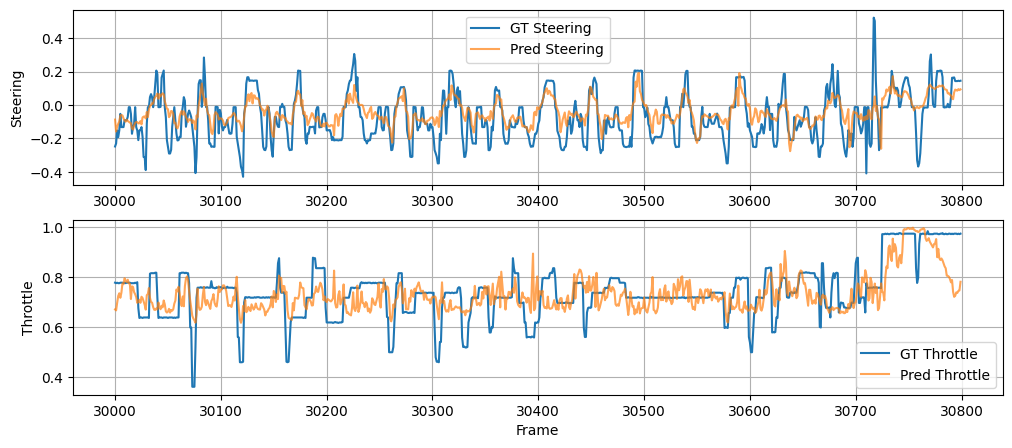

In [43]:

import matplotlib.pyplot as plt

# Use closed-loop rollout over a range
preds, gts = closed_loop_rollout_range(model, X_all, Y_all, FRAMES_PER_BLOCK, start=30000, end=30800)

frames = np.arange(30000, 30800)

plt.figure(figsize=(12,5))

# Steering
plt.subplot(2,1,1)
plt.plot(frames, gts[:,0], label='GT Steering')
plt.plot(frames, preds[:,0], label='Pred Steering', alpha=0.7)
plt.ylabel('Steering')
plt.legend()
plt.grid(True)

# Throttle
plt.subplot(2,1,2)
plt.plot(frames, gts[:,1], label='GT Throttle')
plt.plot(frames, preds[:,1], label='Pred Throttle', alpha=0.7)
plt.ylabel('Throttle')
plt.xlabel('Frame')
plt.legend()
plt.grid(True)

plt.show()


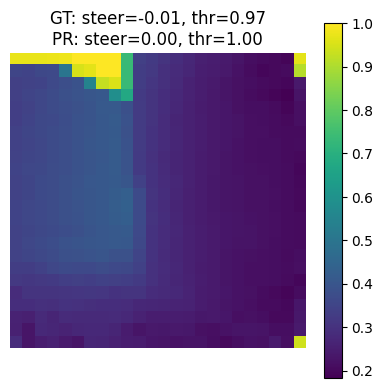

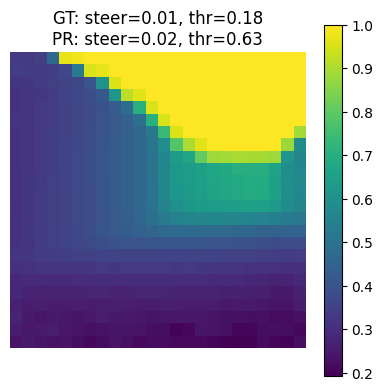

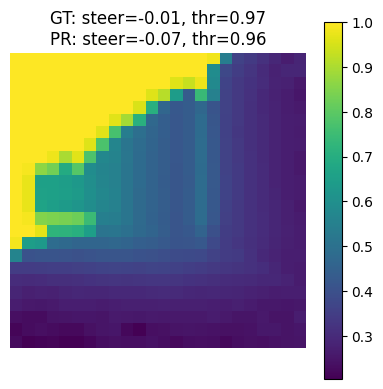

In [54]:
import numpy as np
import matplotlib.pyplot as plt

def inspect_frame(idx, X, y_true, y_pred):
    """
    idx: sample index
    X: 4D array (N, H, W, C)
    y_true: ground truth array (N, 2)
    y_pred: predicted array or list of arrays
    """
    # Handle multi-output predictions
    if isinstance(y_pred, list):
        y_pred_combined = np.stack([y_pred[0].ravel(), y_pred[1].ravel()], axis=1)
    else:
        y_pred_combined = y_pred

    frame = X[idx, :, :, 0]  # (H, W)
    
    plt.figure(figsize=(4, 4))
    plt.imshow(frame, cmap="viridis", vmin=frame.min(), vmax=frame.max())
    plt.colorbar()
    plt.title(
        f"GT: steer={y_true[idx,0]:.2f}, thr={y_true[idx,1]:.2f}\n"
        f"PR: steer={y_pred_combined[idx,0]:.2f}, thr={y_pred_combined[idx,1]:.2f}"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()


# Example usage
inspect_frame(5, X_temp, y_temp, y_pred)
inspect_frame(10, X_temp, y_temp, y_pred)
inspect_frame(15, X_temp, y_temp, y_pred)

In [ ]:
def representative_dataset():
    for i in range(len(X_train)):  # Use ALL training data
        yield [X[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

with open("output/model_int8.tflite", "wb") as f:
    f.write(tflite_model)

print(f"Saved: {len(tflite_model) / 1024:.1f} KB")

INFO:tensorflow:Assets written to: /tmp/tmpu5x0n_22/assets


INFO:tensorflow:Assets written to: /tmp/tmpu5x0n_22/assets


Saved artifact at '/tmp/tmpu5x0n_22'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 24, 20), dtype=tf.float32, name='keras_tensor_70')
Output Type:
  List[TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  140363440965392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140363440965200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140359393292944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140359393293520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140363441443024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140363441446480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140363441445712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140363441448976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140363441228496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140359393281616: T

/home/regularpooria/Projects/tinynav_cnn/venv/lib64/python3.13/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1771544740.812317   11661 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1771544740.812329   11661 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-02-19 18:45:40.812440: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpu5x0n_22
2026-02-19 18:45:40.813866: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-02-19 18:45:40.813872: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpu5x0n_22
2026-02-19 18:45:40.822865: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-02-19 18:45:40.876330: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel 

Saved: 43.1 KB


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
2026-02-19 18:45:42.509887: W tensorflow/compiler/mlir/lite/flatbuffer_export.cc:3705] Skipping runtime version metadata in the model. This will be generated by the exporter.


In [ ]:
interpreter = tf.lite.Interpreter(model_path="output/model_int8.tflite")
interpreter.allocate_tensors()

in_info = interpreter.get_input_details()[0]
out_info = interpreter.get_output_details()[0]

print("Input shape:", in_info["shape"])
print("Input dtype:", in_info["dtype"])
print("Input quant:", in_info["quantization"])

print("Output dtype:", out_info["dtype"])
print("Output quant:", out_info["quantization"])

from tensorflow.lite.python import analyzer

with open("output/model_int8.tflite", "rb") as f:
    model_content = f.read()

print(analyzer.ModelAnalyzer.analyze(
    model_content=model_content,
    gpu_compatibility=False))



Input shape: [ 1 24 24 20]
Input dtype: <class 'numpy.int8'>
Input quant: (0.003921568859368563, -128)
Output dtype: <class 'numpy.int8'>
Output quant: (0.00390625, -128)
=== TFLite ModelAnalyzer ===

Your TFLite model has '1' subgraph(s). In the subgraph description below,
T# represents the Tensor numbers. For example, in Subgraph#0, the CONV_2D op takes
tensor #0 and tensor #17 and tensor #16 as input and produces tensor #18 as output.

Subgraph#0 main(T#0) -> [T#30, T#28]
  Op#0 CONV_2D(T#0, T#17, T#16[-3521, -3613, 3624, -3351, -1810, ...]) -> [T#18]
  Op#1 CONV_2D(T#18, T#15, T#14[-753, 3307, 158, -2286, 401, ...]) -> [T#19]
  Op#2 CONV_2D(T#19, T#13, T#12[-945, -978, -31, -168, -238, ...]) -> [T#20]
  Op#3 CONV_2D(T#20, T#11, T#10[88, -657, -679, -443, -366, ...]) -> [T#21]
  Op#4 CONV_2D(T#21, T#9, T#8[407]) -> [T#22]
  Op#5 LOGISTIC(T#22) -> [T#23]
  Op#6 MUL(T#21, T#23) -> [T#24]
  Op#7 MEAN(T#24, T#1[1, 2]) -> [T#25]
  Op#8 FULLY_CONNECTED(T#25, T#7, T#6[376, 1678, -2409, 710

/home/regularpooria/Projects/tinynav_cnn/venv/lib64/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Running inference on validation set...

Processing 1797 validation samples...

COMPARISON: Float Model vs Quantized (int8) Model

STEERING:
  MAE (quantization error): 0.003794
  RMSE: 0.004907
  Correlation: 0.999410
  Float range: [-0.545, 0.802]
  Int8 range:  [-0.547, 0.805]

THROTTLE:
  MAE (quantization error): 0.004623
  RMSE: 0.006203
  Correlation: 0.999096
  Float range: [0.020, 1.000]
  Int8 range:  [0.020, 0.996]

ACCURACY vs Ground Truth (y_val)

FLOAT MODEL:
  Steering MAE: 0.103517
  Throttle MAE: 0.094156

QUANTIZED MODEL:
  Steering MAE: 0.103528
  Throttle MAE: 0.094015


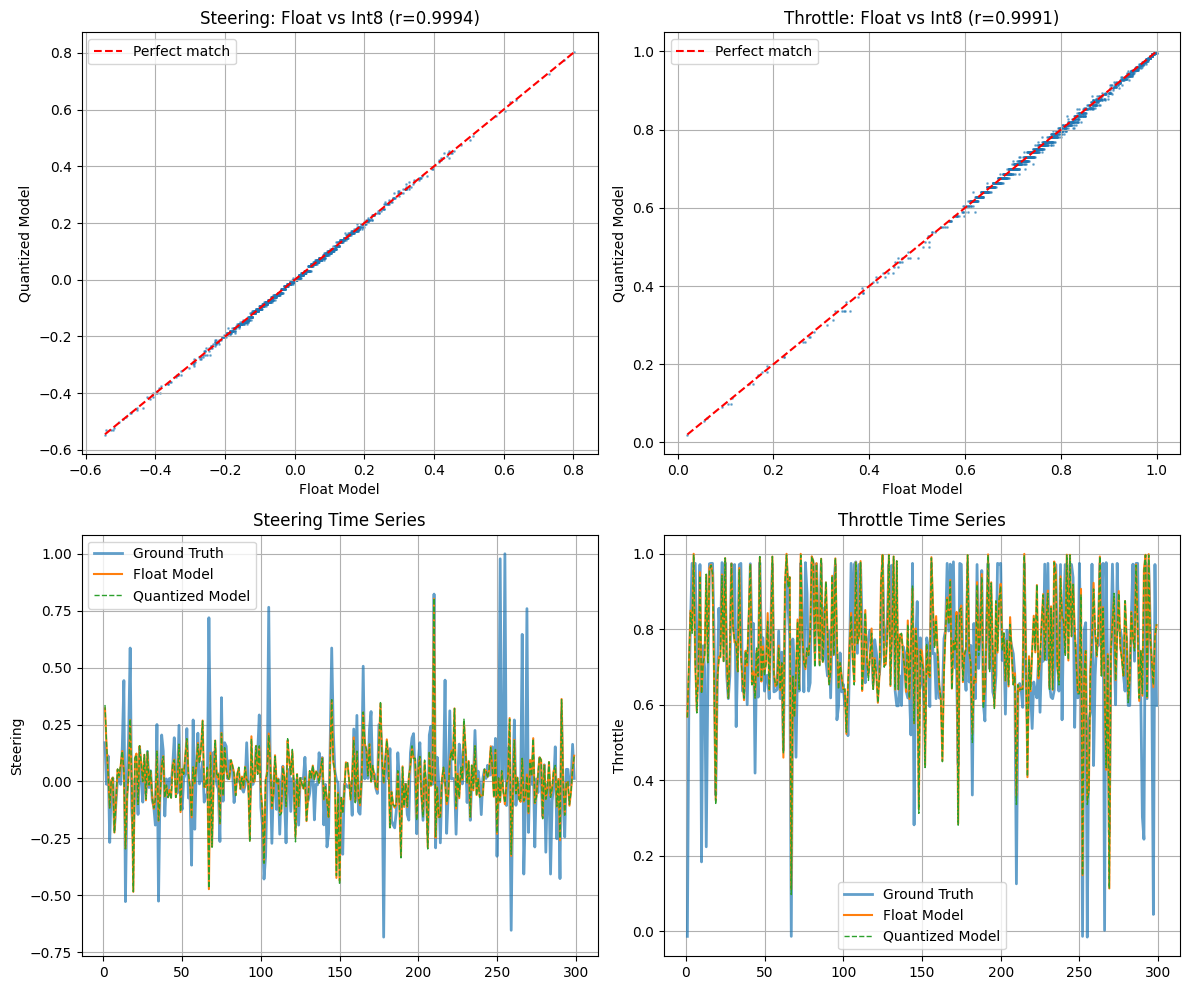

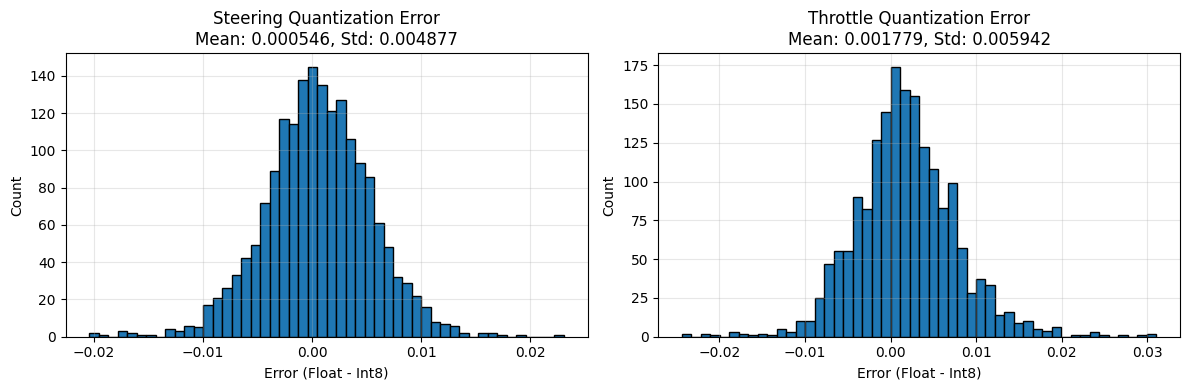

In [ ]:
# Load original model
model = tf.keras.models.load_model("output/best_model.keras")

# Get predictions from both models on validation set
print("Running inference on validation set...")

# Original float model
y_pred_float = model.predict(X_temp, batch_size=64, verbose=0)
steering_float = y_pred_float[0].flatten()
throttle_float = y_pred_float[1].flatten()

# Quantized int8 model
steering_int8_list = []
throttle_int8_list = []

interpreter = tf.lite.Interpreter(model_path="output/model_int8.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_scale, input_zero = input_details[0]['quantization']

# FIXED: Output 0 is THROTTLE, Output 1 is STEERING (swapped!)
throttle_scale, throttle_zero = output_details[0]['quantization']  # Output 0 = throttle
steering_scale, steering_zero = output_details[1]['quantization']  # Output 1 = steering

print(f"\nProcessing {len(X_temp)} validation samples...")
for i in range(len(X_temp)):
    # Quantize input
    test_input = X_temp[i:i+1].astype(np.float32)
    test_input_int8 = (test_input / input_scale + input_zero).astype(np.int8)

    # Run inference
    interpreter.set_tensor(input_details[0]['index'], test_input_int8)
    interpreter.invoke()

    # FIXED: Get outputs in correct order
    throttle_raw = interpreter.get_tensor(output_details[0]['index'])[0][0]  # Output 0 = throttle
    steering_raw = interpreter.get_tensor(output_details[1]['index'])[0][0]  # Output 1 = steering

    # Dequantize
    steering_dequant = (float(steering_raw) - steering_zero) * steering_scale
    throttle_dequant = (float(throttle_raw) - throttle_zero) * throttle_scale

    steering_int8_list.append(steering_dequant)
    throttle_int8_list.append(throttle_dequant)

steering_int8 = np.array(steering_int8_list)
throttle_int8 = np.array(throttle_int8_list)

# Compare predictions
print("\n" + "="*60)
print("COMPARISON: Float Model vs Quantized (int8) Model")
print("="*60)

# Steering comparison
steering_mae = np.mean(np.abs(steering_float - steering_int8))
steering_rmse = np.sqrt(np.mean((steering_float - steering_int8)**2))
steering_corr = np.corrcoef(steering_float, steering_int8)[0, 1]

print(f"\nSTEERING:")
print(f"  MAE (quantization error): {steering_mae:.6f}")
print(f"  RMSE: {steering_rmse:.6f}")
print(f"  Correlation: {steering_corr:.6f}")
print(f"  Float range: [{steering_float.min():.3f}, {steering_float.max():.3f}]")
print(f"  Int8 range:  [{steering_int8.min():.3f}, {steering_int8.max():.3f}]")

# Throttle comparison
throttle_mae = np.mean(np.abs(throttle_float - throttle_int8))
throttle_rmse = np.sqrt(np.mean((throttle_float - throttle_int8)**2))
throttle_corr = np.corrcoef(throttle_float, throttle_int8)[0, 1]

print(f"\nTHROTTLE:")
print(f"  MAE (quantization error): {throttle_mae:.6f}")
print(f"  RMSE: {throttle_rmse:.6f}")
print(f"  Correlation: {throttle_corr:.6f}")
print(f"  Float range: [{throttle_float.min():.3f}, {throttle_float.max():.3f}]")
print(f"  Int8 range:  [{throttle_int8.min():.3f}, {throttle_int8.max():.3f}]")

# Ground truth comparison
print(f"\n" + "="*60)
print("ACCURACY vs Ground Truth (y_val)")
print("="*60)

y_val_steering = y_temp[:, 0]
y_val_throttle = y_temp[:, 1]

print(f"\nFLOAT MODEL:")
print(f"  Steering MAE: {np.mean(np.abs(y_val_steering - steering_float)):.6f}")
print(f"  Throttle MAE: {np.mean(np.abs(y_val_throttle - throttle_float)):.6f}")

print(f"\nQUANTIZED MODEL:")
print(f"  Steering MAE: {np.mean(np.abs(y_val_steering - steering_int8)):.6f}")
print(f"  Throttle MAE: {np.mean(np.abs(y_val_throttle - throttle_int8)):.6f}")

# Rest of visualization code stays the same...

# Visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Steering scatter: Float vs Int8
axes[0, 0].scatter(steering_float, steering_int8, s=1, alpha=0.5)
axes[0, 0].plot([steering_float.min(), steering_float.max()],
                [steering_float.min(), steering_float.max()], 'r--', label='Perfect match')
axes[0, 0].set_xlabel('Float Model')
axes[0, 0].set_ylabel('Quantized Model')
axes[0, 0].set_title(f'Steering: Float vs Int8 (r={steering_corr:.4f})')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Throttle scatter: Float vs Int8
axes[0, 1].scatter(throttle_float, throttle_int8, s=1, alpha=0.5)
axes[0, 1].plot([throttle_float.min(), throttle_float.max()],
                [throttle_float.min(), throttle_float.max()], 'r--', label='Perfect match')
axes[0, 1].set_xlabel('Float Model')
axes[0, 1].set_ylabel('Quantized Model')
axes[0, 1].set_title(f'Throttle: Float vs Int8 (r={throttle_corr:.4f})')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Time series comparison (steering)
n_start, n_end = 1, 300
t = range(n_start, n_end)
axes[1, 0].plot(t, y_val_steering[n_start:n_end], label='Ground Truth', linewidth=2, alpha=0.7)
axes[1, 0].plot(t, steering_float[n_start:n_end], label='Float Model', linewidth=1.5)
axes[1, 0].plot(t, steering_int8[n_start:n_end], label='Quantized Model', linewidth=1, linestyle='--')
axes[1, 0].set_ylabel('Steering')
axes[1, 0].set_title('Steering Time Series')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Time series comparison (throttle)
axes[1, 1].plot(t, y_val_throttle[n_start:n_end], label='Ground Truth', linewidth=2, alpha=0.7)
axes[1, 1].plot(t, throttle_float[n_start:n_end], label='Float Model', linewidth=1.5)
axes[1, 1].plot(t, throttle_int8[n_start:n_end], label='Quantized Model', linewidth=1, linestyle='--')
axes[1, 1].set_ylabel('Throttle')
axes[1, 1].set_title('Throttle Time Series')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Error distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

steering_error = steering_float - steering_int8
throttle_error = throttle_float - throttle_int8

axes[0].hist(steering_error, bins=50, edgecolor='black')
axes[0].set_xlabel('Error (Float - Int8)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Steering Quantization Error\nMean: {steering_error.mean():.6f}, Std: {steering_error.std():.6f}')
axes[0].grid(True, alpha=0.3)

axes[1].hist(throttle_error, bins=50, edgecolor='black')
axes[1].set_xlabel('Error (Float - Int8)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Throttle Quantization Error\nMean: {throttle_error.mean():.6f}, Std: {throttle_error.std():.6f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
%%bash
TFLITE_FILE="output/model_int8.tflite"
BASENAME="output/model"
SYMBOL="g_model"
HEADER_GUARD="MODEL_H_"

set -e

# model.cc
cat > ${BASENAME}.cc <<EOF
#include "${BASENAME}.h"

alignas(16) const unsigned char ${SYMBOL}[] = {
EOF

xxd -i ${TFLITE_FILE} \
  | sed -n '/{/,/}/p' \
  | sed '1d;$d' \
  | sed 's/^/  /' \
  >> ${BASENAME}.cc

cat >> ${BASENAME}.cc <<EOF
};

const int ${SYMBOL}_len = sizeof(${SYMBOL});
EOF

# model.h
cat > ${BASENAME}.h <<EOF
#ifndef ${HEADER_GUARD}
#define ${HEADER_GUARD}

extern const unsigned char ${SYMBOL}[];
extern const int ${SYMBOL}_len;

#endif  // ${HEADER_GUARD}
EOF
